### Assignment-5
##### Implement K-Means clustering/ hierarchical clustering on sales_data_sample.csv dataset.Determine the number of clusters using the elbow method.
Dataset link : https://www.kaggle.com/datasets/kyanyoga/sample-sales-data

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [69]:
df = pd.read_csv("sales_data_sample.csv", encoding="latin")

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [71]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [72]:
#Getting the relevant columns for clustering
X=df[['QUANTITYORDERED','PRICEEACH','SALES']]
X

,QUANTITYORDERED,PRICEEACH,SALES
0,30,95.70,2871.00
1,34,81.35,2765.90
2,41,94.74,3884.34
3,45,83.26,3746.70
4,49,100.00,5205.27
...,...,...,...
2818,20,100.00,2244.40
2819,29,100.00,3978.51
2820,43,100.00,5417.57
2821,34,62.24,2116.16


In [74]:
X.dropna()
X.isnull().sum()

QUANTITYORDERED    0
PRICEEACH          0
SALES              0
dtype: int64

In [75]:
#Scaling 
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(X)
x_scaled

array([[-0.52289086,  0.5969775 , -0.37082523],
       [-0.11220131, -0.11445035, -0.42789707],
       [ 0.60650538,  0.54938372,  0.17944282],
       ...,
       [ 0.81185016,  0.81015797,  1.01202368],
       [-0.11220131, -1.06186404, -0.78072155],
       [ 1.2225397 , -0.89925195, -0.25763729]])

#### Elbow Method: The Elbow Method is a technique to determine the optimal number of clusters (k) in K-Means clustering.

#### Inertia: Inertia measures how tight the clusters are, Think of it like bending an arm: the elbow is the point where adding more clusters doesn’t give much improvement.
1. Lower inertia → points are closer to cluster centers → better clustering.
   
3. But inertia always decreases with more clusters, which is why we need the elbow method to pick a practical k.
   
4. Before the elbow (with fewer clusters): inertia is higher because each cluster has to cover more points that are far from the cluster center.

5. At the elbow: inertia drops significantly as you add clusters, meaning the clustering fits the data better.

6. After the elbow: adding more clusters only slightly reduces inertia, because the points are already close to some cluster cent

In [76]:
from sklearn.cluster import KMeans

# Elbow method to find optimal number of clusters
# Inertia represents how well the clusters formed by the K-Means algorithm fit the data points.
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

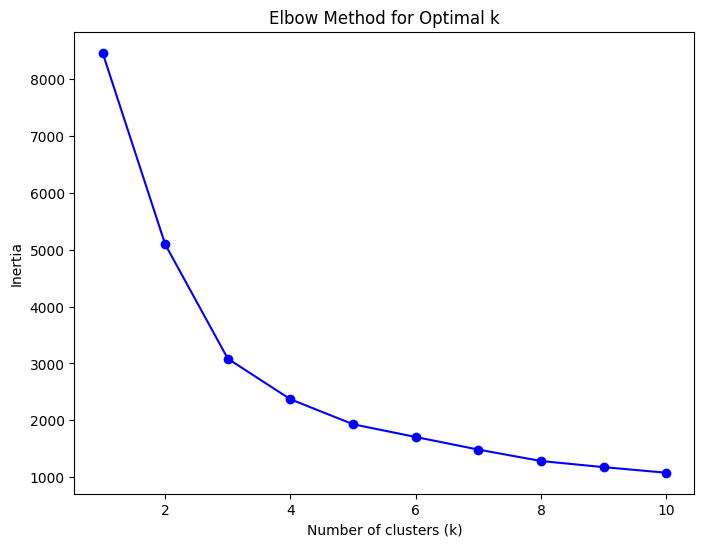

In [77]:
# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.title('Elbow Method for Optimal k')
plt.show()

In [79]:
# Optimal K = 4
kmeans = KMeans(n_clusters=4)
kmeans.fit(x_scaled)
clusters = kmeans.predict(x_scaled)
centroids = kmeans.cluster_centers_

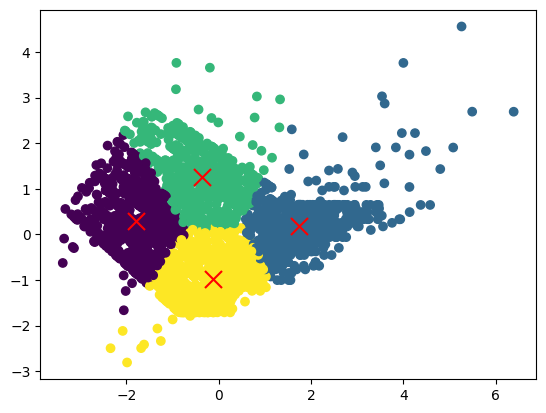

In [80]:
from sklearn.decomposition import PCA

# Reduce the dimensions of the data to 2
# to visualize it on a 2D plane
pca = PCA(2)
reduced_dataset = pca.fit_transform(x_scaled)
reduced_centroids = pca.transform(centroids)

plt.scatter(reduced_dataset[:,0], reduced_dataset[:,1], c=clusters, cmap='viridis')
plt.scatter(reduced_centroids[:,0], reduced_centroids[:,1], marker='x', s=150, c='r')

In [82]:
#optimal k value=4
optimal_k=4
kmeans=KMeans(n_clusters=optimal_k)
df['Clusters']=kmeans.fit_predict(x_scaled)
df[['QUANTITYORDERED','PRICEEACH','SALES','Clusters']]

,QUANTITYORDERED,PRICEEACH,SALES,Clusters
0,30,95.70,2871.00,1
1,34,81.35,2765.90,1
2,41,94.74,3884.34,3
3,45,83.26,3746.70,3
4,49,100.00,5205.27,3
...,...,...,...,...
2818,20,100.00,2244.40,1
2819,29,100.00,3978.51,1
2820,43,100.00,5417.57,3
2821,34,62.24,2116.16,0


In [83]:
#It measures how well points fit their own cluster vs others, ranging −1 to 1;
#higher means clearer separation
from sklearn.metrics import silhouette_score

score = silhouette_score(x_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.42171955327252236


In [84]:
#Statistics for clusters
# Add cluster labels to original data
df['Cluster'] = kmeans.labels_

# Print cluster centroids
print("Cluster Centroids (in scaled units):")
print(kmeans.cluster_centers_)

# Count samples per cluster
print("\nNumber of samples in each cluster:")
print(df['Cluster'].value_counts())




Cluster Centroids (in scaled units):
[[-0.06579643 -1.38371978 -0.89109832]
 [-0.94539123  0.55338827 -0.31834235]
 [ 1.13147376  0.80185349  1.96582869]
 [ 0.62578903  0.45820572  0.41226588]]

Number of samples in each cluster:
Cluster
1    878
0    811
3    785
2    349
Name: count, dtype: int64
